# 2.2. Decision tree behaviour

In [1]:
from anchoring_detection.models import Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


dataset = pd.read_pickle('/home/arturo/Documentos/Mooring_anomaly_detector/data/dataframe.pkl')

In [2]:
dataset

,Hs,Tp,Direction,m0_Surge,m0_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.001749,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.008595,1
oc4__Hs1__Tp2__dir1__3,1.21,8.15,0,0.005411,0.005698,1
oc4__Hs1__Tp2__dir1__4,1.21,8.15,0,0.002285,0.003390,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.001852,0
...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.018121,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.010878,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.016706,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.002734,0


## Prepare data

The user can apply transformations described in [*models>transform_dataset*](/home/arturo/Documentos/Mooring_anomaly_detector/anchoring_detection/models.py)

In [3]:
drag_models = Models()

In [4]:
X_train_min_max, X_test_min_max, Y_train, Y_test = drag_models.transform_dataset(dataset)

The training set contains the Surge and Sway spectral moments in a 2D array

In [5]:
X_train_min_max

array([[0.00698358, 0.08528962],
       [0.01479205, 0.00191339],
       [0.00537408, 0.10163946],
       [0.07170368, 0.64738316],
       [0.13279204, 0.22928384],
       [0.97379166, 0.44280775],
       [0.02292324, 0.00992097],
       [0.02498603, 0.26900404],
       [0.03661853, 0.00448592],
       [0.46194614, 0.04524715],
       [0.05851568, 0.04525578],
       [0.80010464, 0.28760974],
       [0.00234019, 0.02315467],
       [0.59827887, 0.44251679],
       [0.54892333, 0.06513841],
       [0.59337273, 0.42081638],
       [0.60988548, 0.40667915],
       [0.57558169, 0.42438641],
       [0.67948669, 0.43384154],
       [0.        , 0.02048375],
       [0.61626008, 0.27170729],
       [0.66738549, 0.46234012],
       [0.58478244, 0.42107766],
       [0.02389493, 0.39263281],
       [0.12769059, 0.15162937],
       [0.07700594, 0.10509197],
       [0.61160497, 0.42066791],
       [0.65091093, 0.41372954],
       [0.00869242, 0.01133714],
       [0.01081056, 0.18879129],
       [0.

The approach of training is with supervised learning. It is store the data according two class, **Healthy (0)** and **Draging (1)**

In [6]:
Y_train

oc4__Hs1__Tp5__dir3__1    0
oc4__Hs1__Tp3__dir1__1    0
oc4__Hs1__Tp3__dir1__4    1
oc4__Hs4__Tp5__dir3__1    0
oc4__Hs2__Tp5__dir2__1    0
                         ..
oc4__Hs3__Tp5__dir5__1    0
oc4__Hs1__Tp3__dir1__3    1
oc4__Hs3__Tp4__dir4__1    0
oc4__Hs2__Tp3__dir1__4    1
oc4__Hs3__Tp5__dir3__1    0
Name: Dragging, Length: 96, dtype: int64

## First training

Check how model perform without hyperparams

In [7]:
model = DecisionTreeClassifier(criterion='gini')

In [8]:
model.fit(X_train_min_max,Y_train)

DecisionTreeClassifier()

It is posible to see the tree status

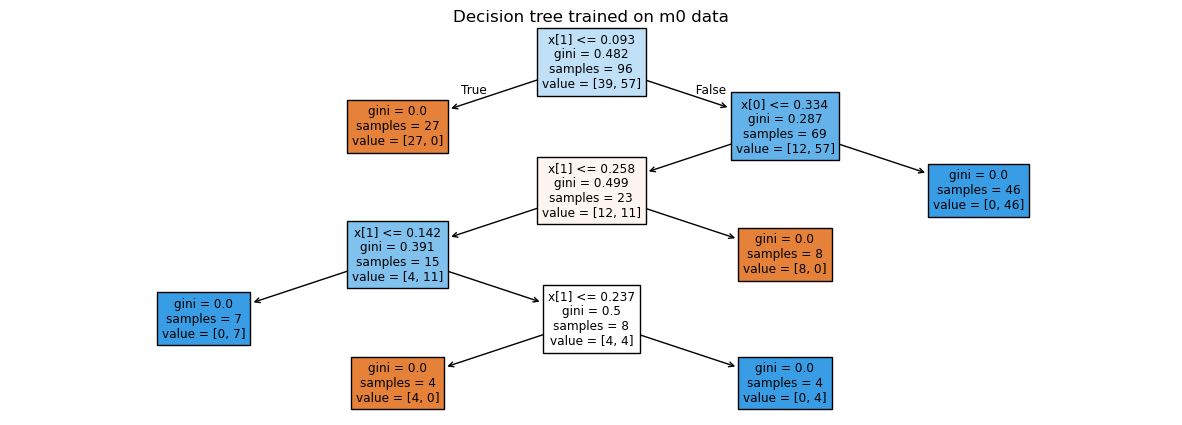

In [9]:
plt.figure(figsize=(15,5))

plot_tree(model, filled=True)
plt.title("Decision tree trained on m0 data")
plt.show()

Due to the orthogonal nature of the decision boundaries in DecisionTree, it very easily falls into overfitting.

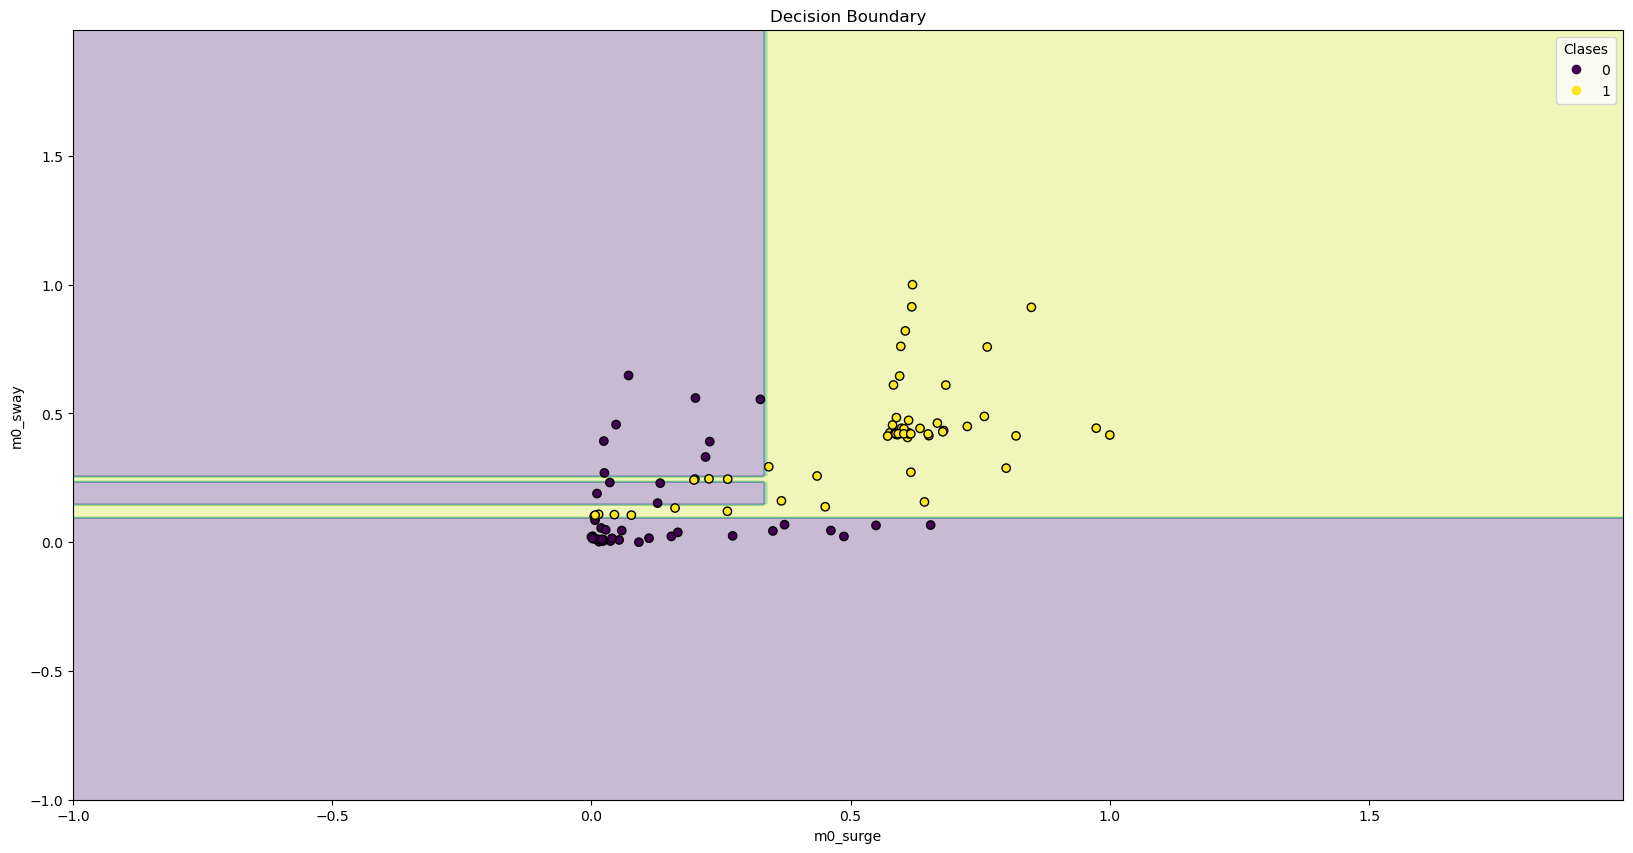

In [10]:
drag_models.decision_boundary(model,X=X_train_min_max,y=Y_train)

Can be made cross validation and see the metrics

In [11]:
train_pred = cross_val_predict(model,X_train_min_max, Y_train, cv=5)

In [12]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

In [13]:
df_metrics

,accuracy,precision,recall,f1
0,0.9375,0.947368,0.947368,0.947368


Text(0.5, 1.0, 'Decision_tree')

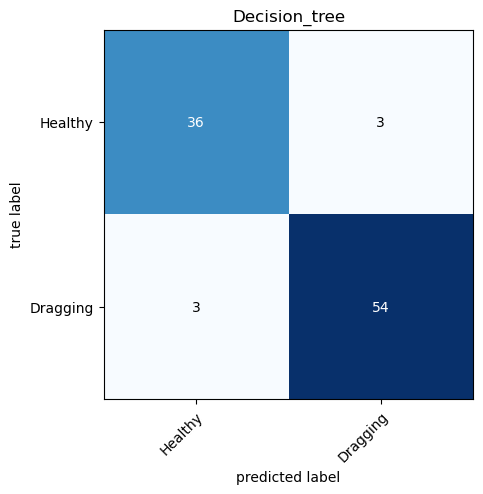

In [14]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision_tree')

## Hyperparams selection

Apply hyperparams to improve the model performance. The main target is reduce the "false healthy states" to the confusion matrix. More information about that in documentation

In [15]:
param_grid = [
    {'max_depth':[2, 3, 4],'min_samples_split':[5,8,10,12],'min_samples_leaf':[4,5,6],'max_leaf_nodes':[2,3,4]},
]

grid_search = GridSearchCV(model, param_grid, cv=5, scoring= ['accuracy','precision','recall','f1'],refit='accuracy', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid=[{'max_depth': [2, 3, 4], 'max_leaf_nodes': [2, 3, 4],
                          'min_samples_leaf': [4, 5, 6],
                          'min_samples_split': [5, 8, 10, 12]}],
             refit='accuracy', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1'])

In [16]:
hyperparams = pd.DataFrame(grid_search.cv_results_)
metric_columns = ['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf','param_max_leaf_nodes', 'mean_train_accuracy', 'mean_train_precision', 'mean_train_recall', 'mean_train_f1']
hyperparams = hyperparams[metric_columns]

hyperparams

,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_leaf_nodes,mean_train_accuracy,mean_train_precision,mean_train_recall,mean_train_f1
0,2,5,4,2,0.880212,0.862616,0.964444,0.905303
1,2,8,4,2,0.880212,0.862616,0.964444,0.905303
2,2,10,4,2,0.880212,0.862616,0.964444,0.905303
3,2,12,4,2,0.880212,0.862616,0.964444,0.905303
4,2,5,5,2,0.880212,0.862616,0.964444,0.905303
...,...,...,...,...,...,...,...,...
103,4,12,5,4,0.968729,0.966922,0.982415,0.973987
104,4,5,6,4,0.968729,0.966922,0.982415,0.973987
105,4,8,6,4,0.968729,0.966922,0.982415,0.973987
106,4,10,6,4,0.968729,0.966922,0.982415,0.973987


In [17]:
grid_search.best_params_

{'max_depth': 3,
 'max_leaf_nodes': 4,
 'min_samples_leaf': 4,
 'min_samples_split': 5}

## New training

Retraining model with hyperparameters

In [18]:
model = DecisionTreeClassifier(max_depth=3,max_leaf_nodes=4,min_samples_leaf=4,min_samples_split=5,criterion='gini')

In [19]:
model.fit(X_train_min_max,Y_train)

DecisionTreeClassifier(max_depth=3, max_leaf_nodes=4, min_samples_leaf=4,
                       min_samples_split=5)

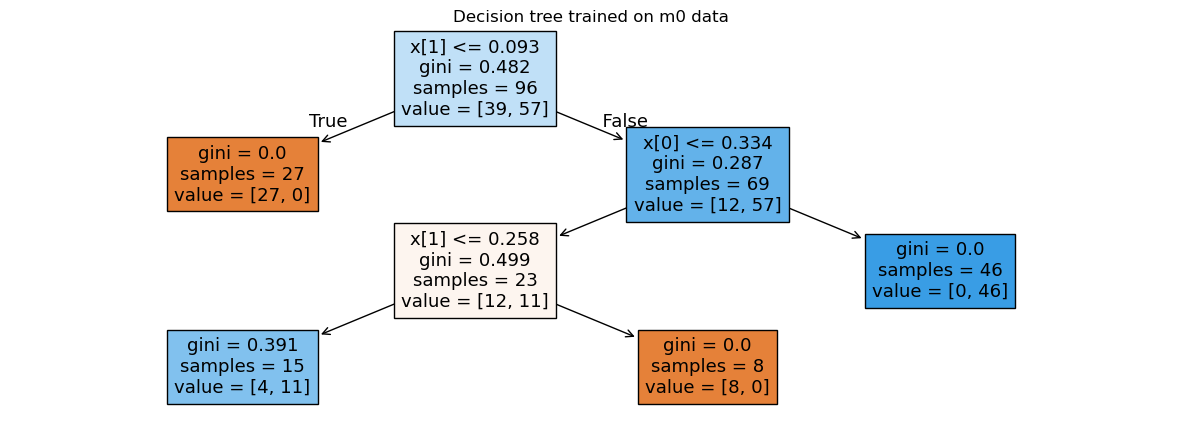

In [20]:
plt.figure(figsize=(15,5))

plot_tree(model, filled=True)
plt.title("Decision tree trained on m0 data")
plt.show()

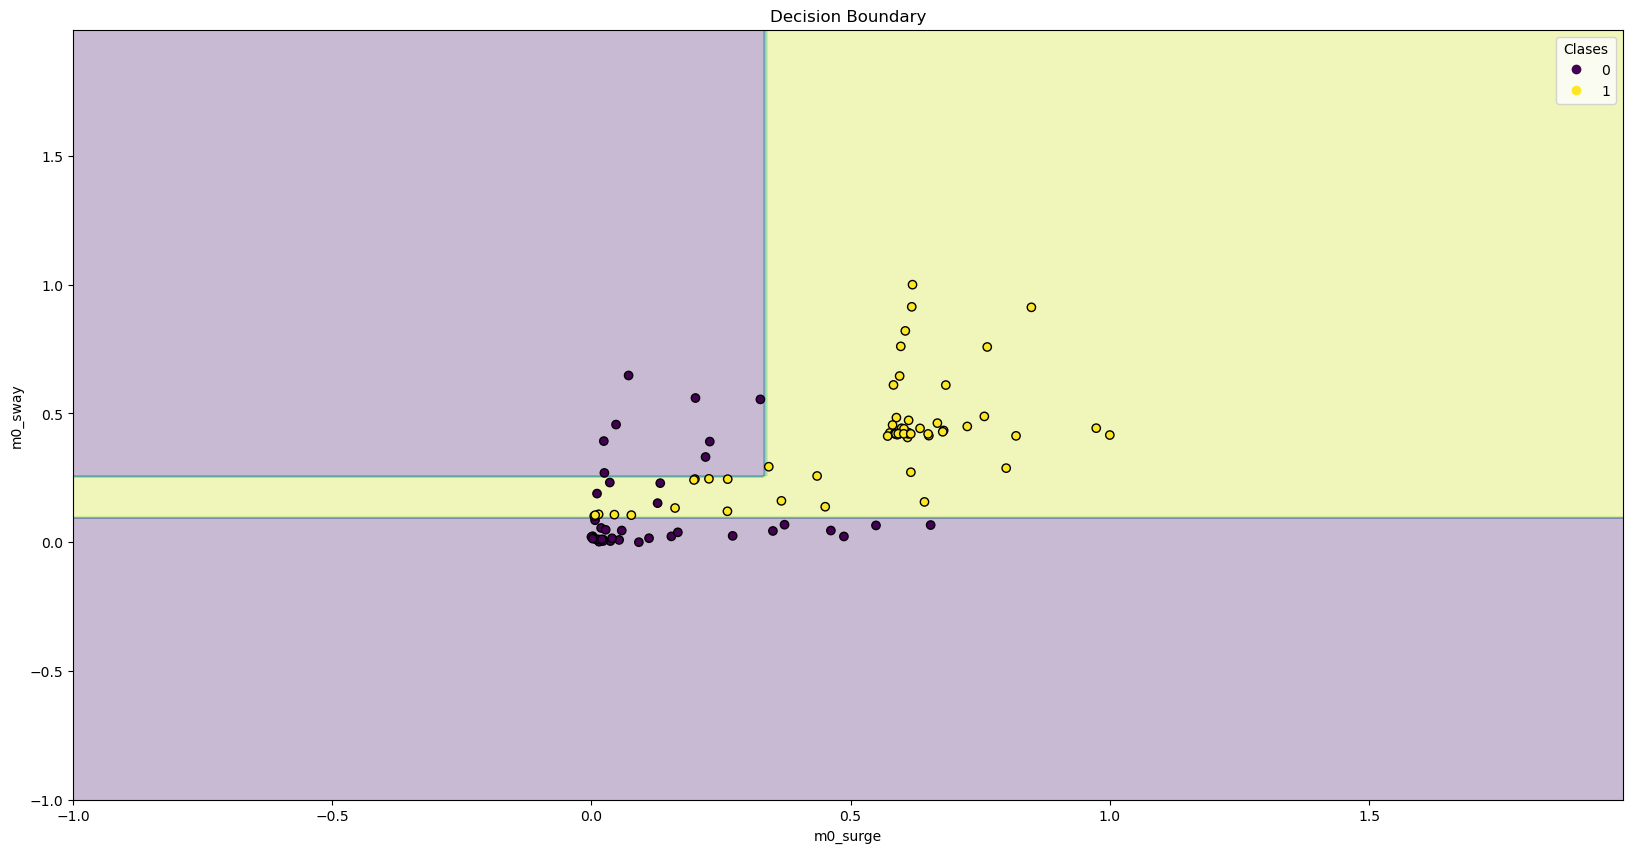

In [21]:
drag_models.decision_boundary(model,X=X_train_min_max,y=Y_train)

In [22]:
train_pred = cross_val_predict(model,X_train_min_max, Y_train, cv=5)

In [23]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

Looking at the results and comparing them to the first training, there is an increase in the ‘false healthy’, however, a more realistic decision boundary is generated, reducing the number of orthogonals to include all data in one class.

Probably, it is recommended try ensemble techniques like Bagging or RandomForest to improve the false instances performance

In [24]:
df_metrics

,accuracy,precision,recall,f1
0,0.854167,0.877193,0.877193,0.877193


Text(0.5, 1.0, 'Decision tree')

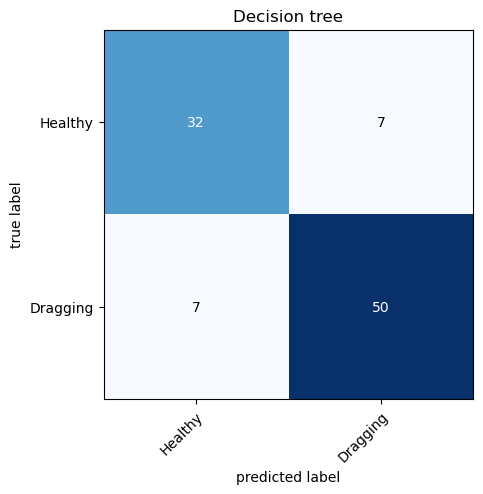

In [25]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

## Predictions

In [26]:
Y_pred_test = model.predict(X_test_min_max)

ATTENTION: Note that you are now working with model test arrays.

In [27]:
cm, df_metrics =drag_models.return_metrics(Y=Y_test, Y_pred=Y_pred_test)

In [28]:
df_metrics

,accuracy,precision,recall,f1
0,0.916667,0.923077,0.923077,0.923077


Text(0.5, 1.0, 'Decision tree')

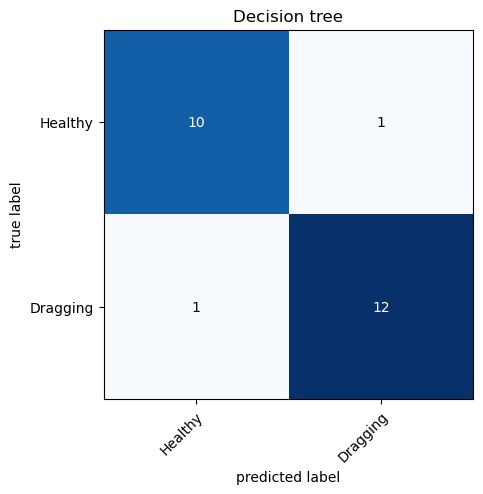

In [29]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

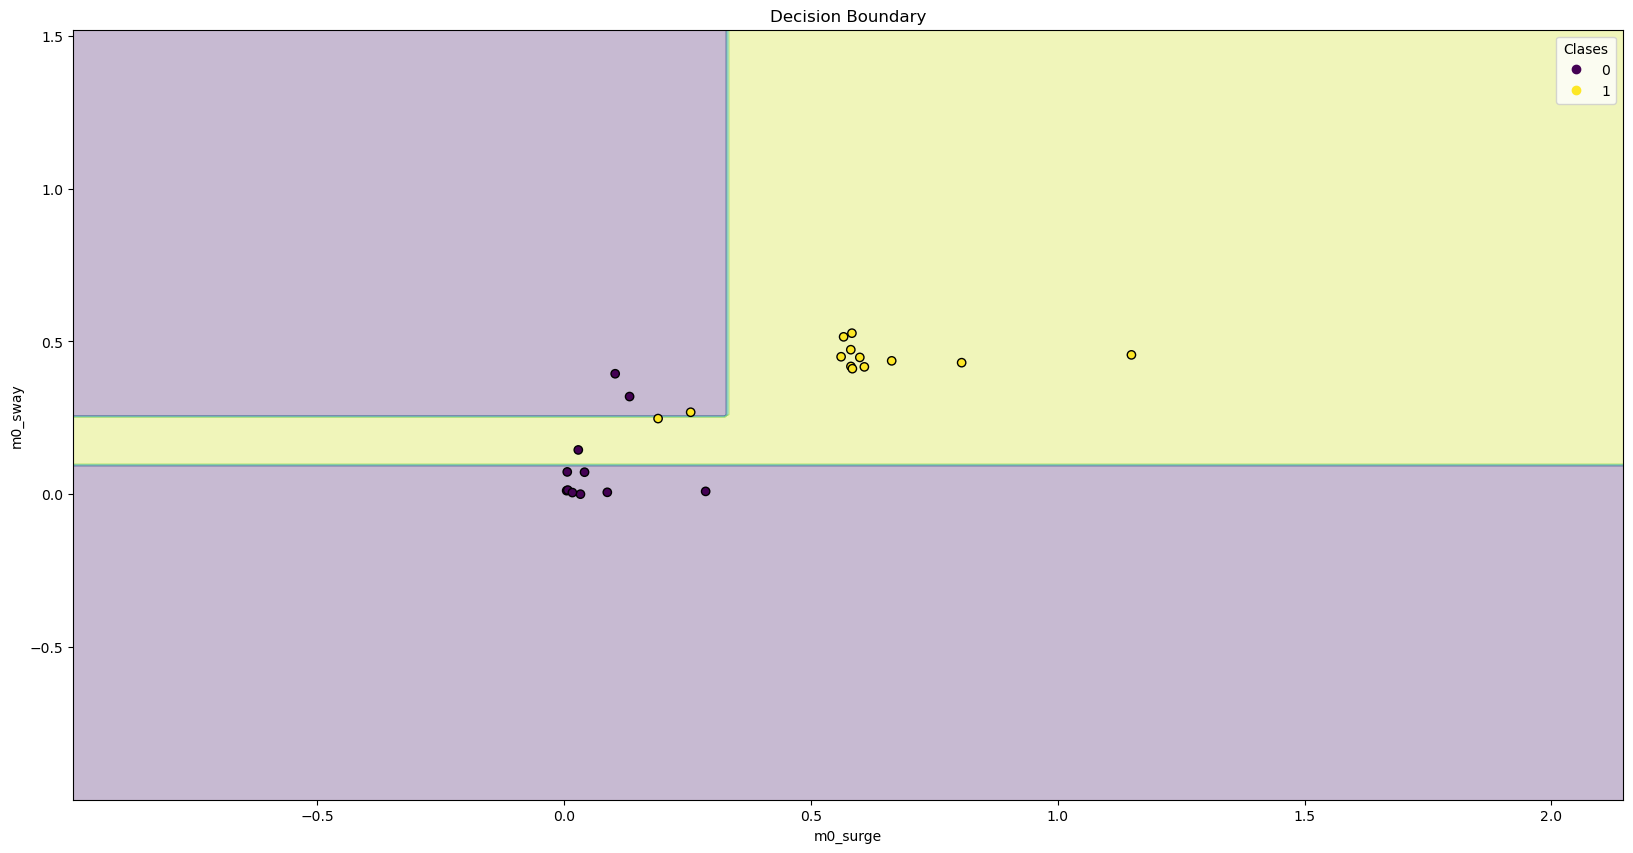

In [30]:
drag_models.decision_boundary(model,X=X_test_min_max,y=Y_test)